# Demo B: Shepp-Logan phantom with random sampling and simulated rigid motion

This example shows how the random sampling can improve the motion correction quality. This toy example serves as an illustration of the logic behind the DISORDER framework (Cordero-Grande et al. MRM 2020, https://doi.org/10.1002/mrm.28157)

[Demo B] Loading config...
[Demo B] Initializing runtime...
[Demo B] Loading data and building operators...
[DataLoader] k-space normalized (rms), scale=1.010733e-01


EspiritCalib:   0%|          | 0/100 [00:00<?, ?it/s]

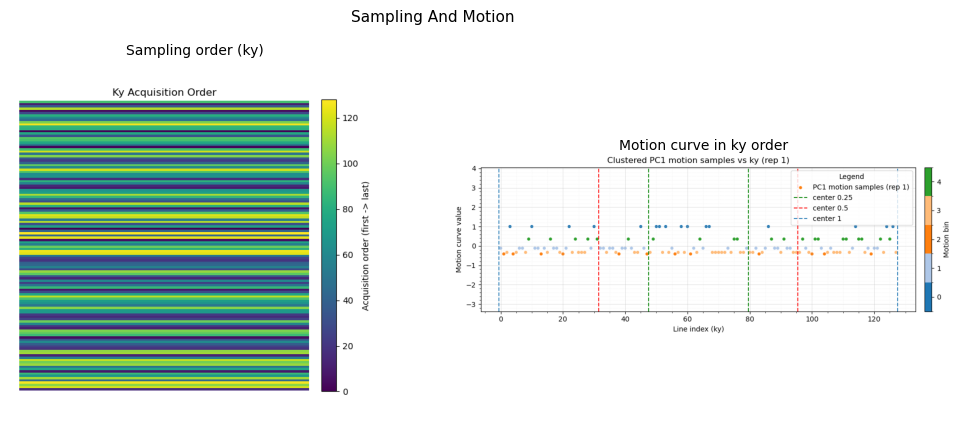

[Demo B] Starting reconstruction...


Resolution level 1/3:   0%|          | 0/8 [00:00<?, ?it/s]

Resolution level 2/3:   0%|          | 0/3 [00:00<?, ?it/s]

Resolution level 3/3:   0%|          | 0/3 [00:00<?, ?it/s]

Elapsed time: 8.55 s


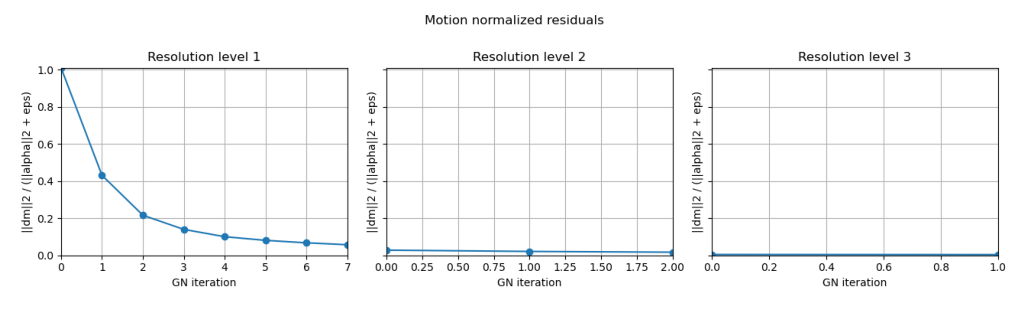

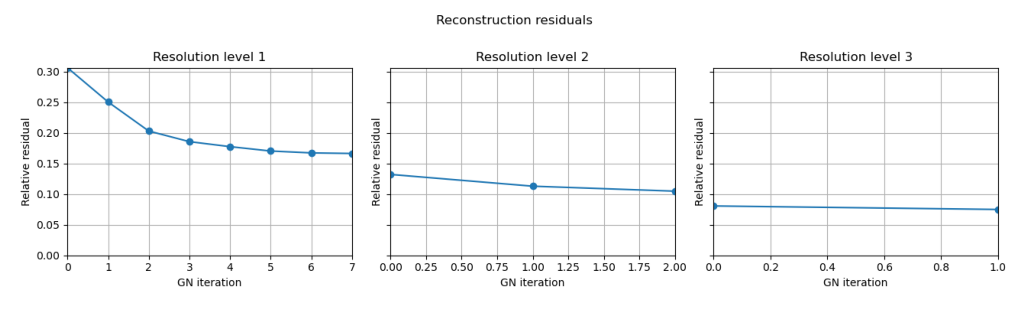

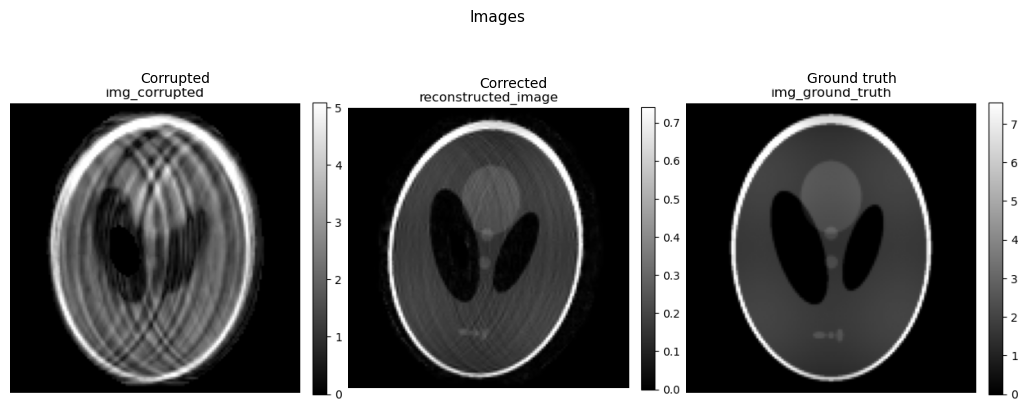

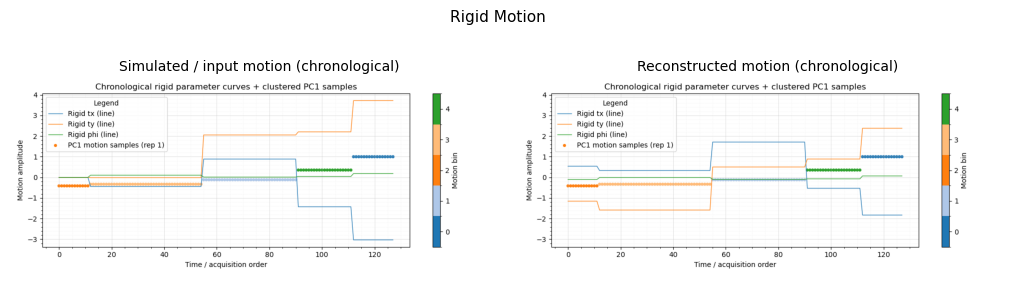

In [1]:
import time

from src.runtime.runtime_config import load_config
from src.preprocessing.DataLoader import DataLoader
from src.reconstruction.JointReconstructor import JointReconstructor
from src.utils.notebook_display import display_input_sampling_motion_panels, display_run_panels
from src.runtime.runtime_setup import initialize_runtime

jupyter_notebook_flag = True

def main():
    print("[Demo B] Loading config...")
    params = load_config(
        data_type="shepp-logan",
        shepp_logan_config="config/shepp_logan.toml",
        reconstruction_config="config/reconstruction/rigid_fast.toml",
        sampling_config="config/sampling_simulation/random.toml",
        motion_simulation_config="config/motion_simulation/rigid.toml",
        overrides={
            "jupyter_notebook_flag": jupyter_notebook_flag,
        },
    )

    print("[Demo B] Initializing runtime...")
    sp_device, t_device = initialize_runtime(params)

    print("[Demo B] Loading data and building operators...")
    data = DataLoader(params=params, t_device=t_device, sp_device=sp_device)
    display_input_sampling_motion_panels(
        params,
    )
    print("[Demo B] Starting reconstruction...")
    recon = JointReconstructor(
        data.kspace,
        data.smaps,
        data.sampling_idx,
        motion_signal=data.motion_signal,
        params=params,
        kspace_scale=data.kspace_scale,
        motion_plot_context=data.motion_plot_context,
    )
    t0 = time.time()
    recon.run()
    print(f"Elapsed time: {time.time() - t0:.2f} s")
    display_run_panels(
        params,
        motion_type=params.motion_type,
    )


if __name__ == "__main__":
    main()
